# Introduction
## GitHub

Project repository:
https://github.com/renteria-luis/pawsclassifier
## Project Goal

This project builds an image classification system capable of identifying 37 distinct cat and dog breeds from the Oxford-IIIT Pets dataset. The core approach is transfer learning using a pretrained ResNet18 backbone, with only the final classification layer retrained on the target dataset.

The project also includes a benchmark comparison between the fine-tuned model and Gemini 2.5 Flash-Lite, a general-purpose vision LLM, to evaluate when a task-specific trained model is competitive against a large-scale API.

## Why Oxford-IIIT Pets

The dataset presents a fine-grained classification challenge: distinguishing 37 breeds across dogs and cats, many of which are visually similar. It is available natively through torchvision, has roughly 200 images per class, and maps directly to the transfer learning paradigm since ImageNet pretraining already includes animal categories. CIFAR and MNIST were excluded per assignment requirements.

# Setup

## Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# Data Preprocessing

## Transforms

Training transforms apply aggressive augmentation: random resized crop (randomly samples a region of the image before resizing, forcing the model to be position-invariant), horizontal flip, and color jitter. Validation and test transforms apply only deterministic resizing and center crop, consistent with ImageNet preprocessing standards used during ResNet pretraining.

Normalization uses ImageNet mean and standard deviation because the ResNet18 backbone was pretrained with those exact values. Using different statistics would cause a distribution mismatch between what the frozen layers expect and what they receive.

In [3]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## Dataset Loading and Splitting

Oxford-IIIT Pets provides an official trainval/test split. The trainval set (3,680 images) is further divided 80/20 into train and validation subsets. To ensure validation uses deterministic transforms (no augmentation), the trainval images are loaded twice under different transform pipelines and the validation indices are applied to the non-augmented copy.

In [4]:
full_train = datasets.OxfordIIITPet(root='data', split='trainval', download=True, transform=train_transforms)
full_val_base = datasets.OxfordIIITPet(root='data', split='trainval', download=False, transform=test_transforms)
full_test = datasets.OxfordIIITPet(root='data', split='test', download=True, transform=test_transforms)

indices = list(range(len(full_train)))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_data = Subset(full_train, train_idx)
val_data   = Subset(full_val_base, val_idx)
test_data  = full_test

class_names = full_test.classes
print(f'Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')
print(f'Classes: {len(class_names)}')

Train: 2944 | Val: 736 | Test: 3669
Classes: 37


## DataLoaders

Batch size 32 is used throughout. `num_workers=4` enables parallel image loading while the GPU processes the previous batch. `pin_memory=True` speeds up CPU-to-GPU transfers.

In [5]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

Train batches: 92 | Val batches: 23 | Test batches: 115


# Model Architecture

## Transfer Learning with ResNet18

ResNet18 was pretrained on ImageNet (1.2 million images, 1,000 classes). Its convolutional layers already encode rich visual features: early layers detect edges and textures, middle layers detect shapes and parts, deep layers detect semantic concepts like ears, fur, and facial structure.

The strategy is to freeze all backbone weights and replace only the final fully connected layer (fc), which originally mapped 512 features to 1,000 ImageNet classes. The new layer maps 512 features to 37 breed classes. Only this layer is trained, which reduces compute dramatically and avoids overfitting on the small dataset.

**Why not train from scratch?** With 2,944 training images and 37 classes, a CNN trained from scratch would have insufficient data to learn robust visual representations. Transfer learning leverages millions of images of animals already seen during ImageNet pretraining.

In [6]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

print('Original final layer:', model.fc)
model.fc = nn.Linear(512, 37)
print('Fine-tuned final layer:', model.fc)

model = model.to(device)

Original final layer: Linear(in_features=512, out_features=1000, bias=True)
Fine-tuned final layer: Linear(in_features=512, out_features=37, bias=True)


## Optimizer and Loss Function

Adam is applied only to `model.fc.parameters()` since the backbone is frozen. CrossEntropyLoss is used for multi-class classification; it applies Softmax internally, so no Softmax activation is needed in the output layer.

In [7]:
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Training

## Training Loop

Early stopping with `patience=5` monitors validation loss. The best model checkpoint is saved whenever validation loss improves. `model.train()` and `model.eval()` toggle Dropout and BatchNorm behavior across the two phases.

In [8]:
epochs = 30
counter = 0
patience = 5
best_val_loss = float('inf')
train_losses = []
val_losses = []
val_accs = []

for epoch in range(epochs):
    train_loss = 0
    val_loss = 0

    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_correct = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            loss = criterion(output, labels)
            val_loss += loss.item()
            val_correct += (output.argmax(1) == labels).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss   = val_loss   / len(val_loader)
    val_acc = val_correct / len(val_loader.dataset)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    print(f'Epoch {epoch+1}/{epochs} | Accuracy: {val_acc:.4f} | Train Loss: {avg_train_loss:.4f} | Validation Loss: {avg_val_loss:.4f}')

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        counter += 1

    if counter >= patience:
        print('Early stopping')
        break

Epoch 1/30 | Accuracy: 0.7500 | Train Loss: 2.4027 | Validation Loss: 1.1341
Epoch 2/30 | Accuracy: 0.8465 | Train Loss: 1.2571 | Validation Loss: 0.6829
Epoch 3/30 | Accuracy: 0.8560 | Train Loss: 0.9430 | Validation Loss: 0.5271
Epoch 4/30 | Accuracy: 0.8723 | Train Loss: 0.8064 | Validation Loss: 0.4466
Epoch 5/30 | Accuracy: 0.8859 | Train Loss: 0.7649 | Validation Loss: 0.4132
Epoch 6/30 | Accuracy: 0.8940 | Train Loss: 0.6881 | Validation Loss: 0.3668
Epoch 7/30 | Accuracy: 0.8954 | Train Loss: 0.6316 | Validation Loss: 0.3456
Epoch 8/30 | Accuracy: 0.8954 | Train Loss: 0.6352 | Validation Loss: 0.3214
Epoch 9/30 | Accuracy: 0.8886 | Train Loss: 0.5875 | Validation Loss: 0.3329
Epoch 10/30 | Accuracy: 0.9008 | Train Loss: 0.5822 | Validation Loss: 0.3101
Epoch 11/30 | Accuracy: 0.8913 | Train Loss: 0.5909 | Validation Loss: 0.3109
Epoch 12/30 | Accuracy: 0.8995 | Train Loss: 0.5511 | Validation Loss: 0.2795
Epoch 13/30 | Accuracy: 0.9035 | Train Loss: 0.5212 | Validation Loss: 0.

## Training Insights

- Validation loss converged faster than training loss due to Dropout in ResNet being active only during training, reducing effective model capacity per batch
- Early stopping triggered at epoch 21 with best checkpoint at epoch 16 (val loss 0.2547)
- 75% validation accuracy in epoch 1 confirms the pretrained backbone already encodes useful pet features before any weight updates

## Loss Curves

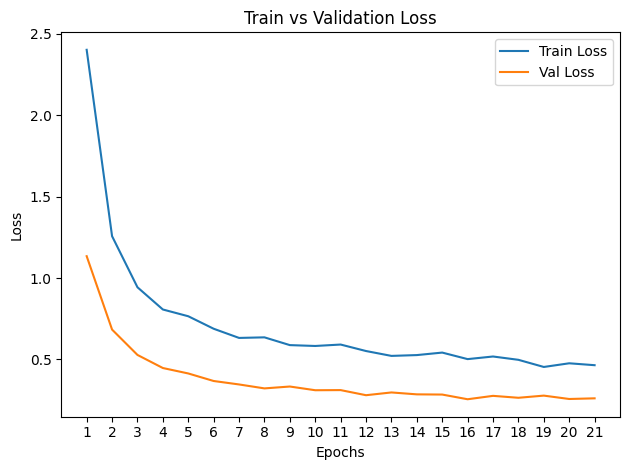

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

epoch_range = list(range(1, len(train_losses) + 1))

plt.figure()
sns.lineplot(x=epoch_range, y=train_losses, label='Train Loss')
sns.lineplot(x=epoch_range, y=val_losses, label='Val Loss')
plt.xticks(epoch_range)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.tight_layout()
plt.show()

# Evaluation

## Test Set Performance

The best checkpoint is loaded and evaluated on the held-out test set (3,669 images). The test set was never seen during training or early stopping decisions.

In [10]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

test_loss = 0
test_correct = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        output = model(images)
        loss = criterion(output, labels)
        test_loss += loss.item()
        test_correct += (output.argmax(1) == labels).sum().item()

test_acc = test_correct / len(test_loader.dataset)
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.8823


**Insight:** 88.23% accuracy on 37 fine-grained classes from a model trained on under 3,000 images demonstrates the power of transfer learning. A CNN trained from scratch on this dataset would likely achieve 20-40%.

## Classification Report

In [11]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        output = model(images)
        preds = output.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [12]:
from sklearn.metrics import classification_report

report = classification_report(all_labels, all_preds, target_names=class_names)
print("Classification Report:\n", report)

Classification Report:
                             precision    recall  f1-score   support

                Abyssinian       0.85      0.80      0.82        98
          American Bulldog       0.71      0.85      0.78       100
 American Pit Bull Terrier       0.75      0.40      0.52       100
              Basset Hound       0.99      0.89      0.94       100
                    Beagle       0.86      0.96      0.91       100
                    Bengal       0.74      0.85      0.79       100
                    Birman       0.66      0.86      0.75       100
                    Bombay       0.87      0.90      0.88        88
                     Boxer       0.83      0.92      0.87        99
         British Shorthair       0.91      0.78      0.84       100
                 Chihuahua       0.89      0.86      0.87       100
              Egyptian Mau       0.87      0.90      0.88        97
    English Cocker Spaniel       0.94      0.96      0.95       100
            English Set

**Insights:**

- Classes 34 (Staffordshire Bull Terrier) and 2 (American Pit Bull Terrier) show the lowest F1 scores (0.62 and 0.56), which is expected: these two breeds share near-identical body structure, coat, and coloring
- Classes like Keeshond (0.99) and Wheaten Terrier (0.98) achieve near-perfect F1, likely because their distinctive silhouettes and coat textures are visually unambiguous
- Macro avg F1 of 0.88 across 37 classes is strong for a single-layer fine-tuning approach

## Confusion Matrix

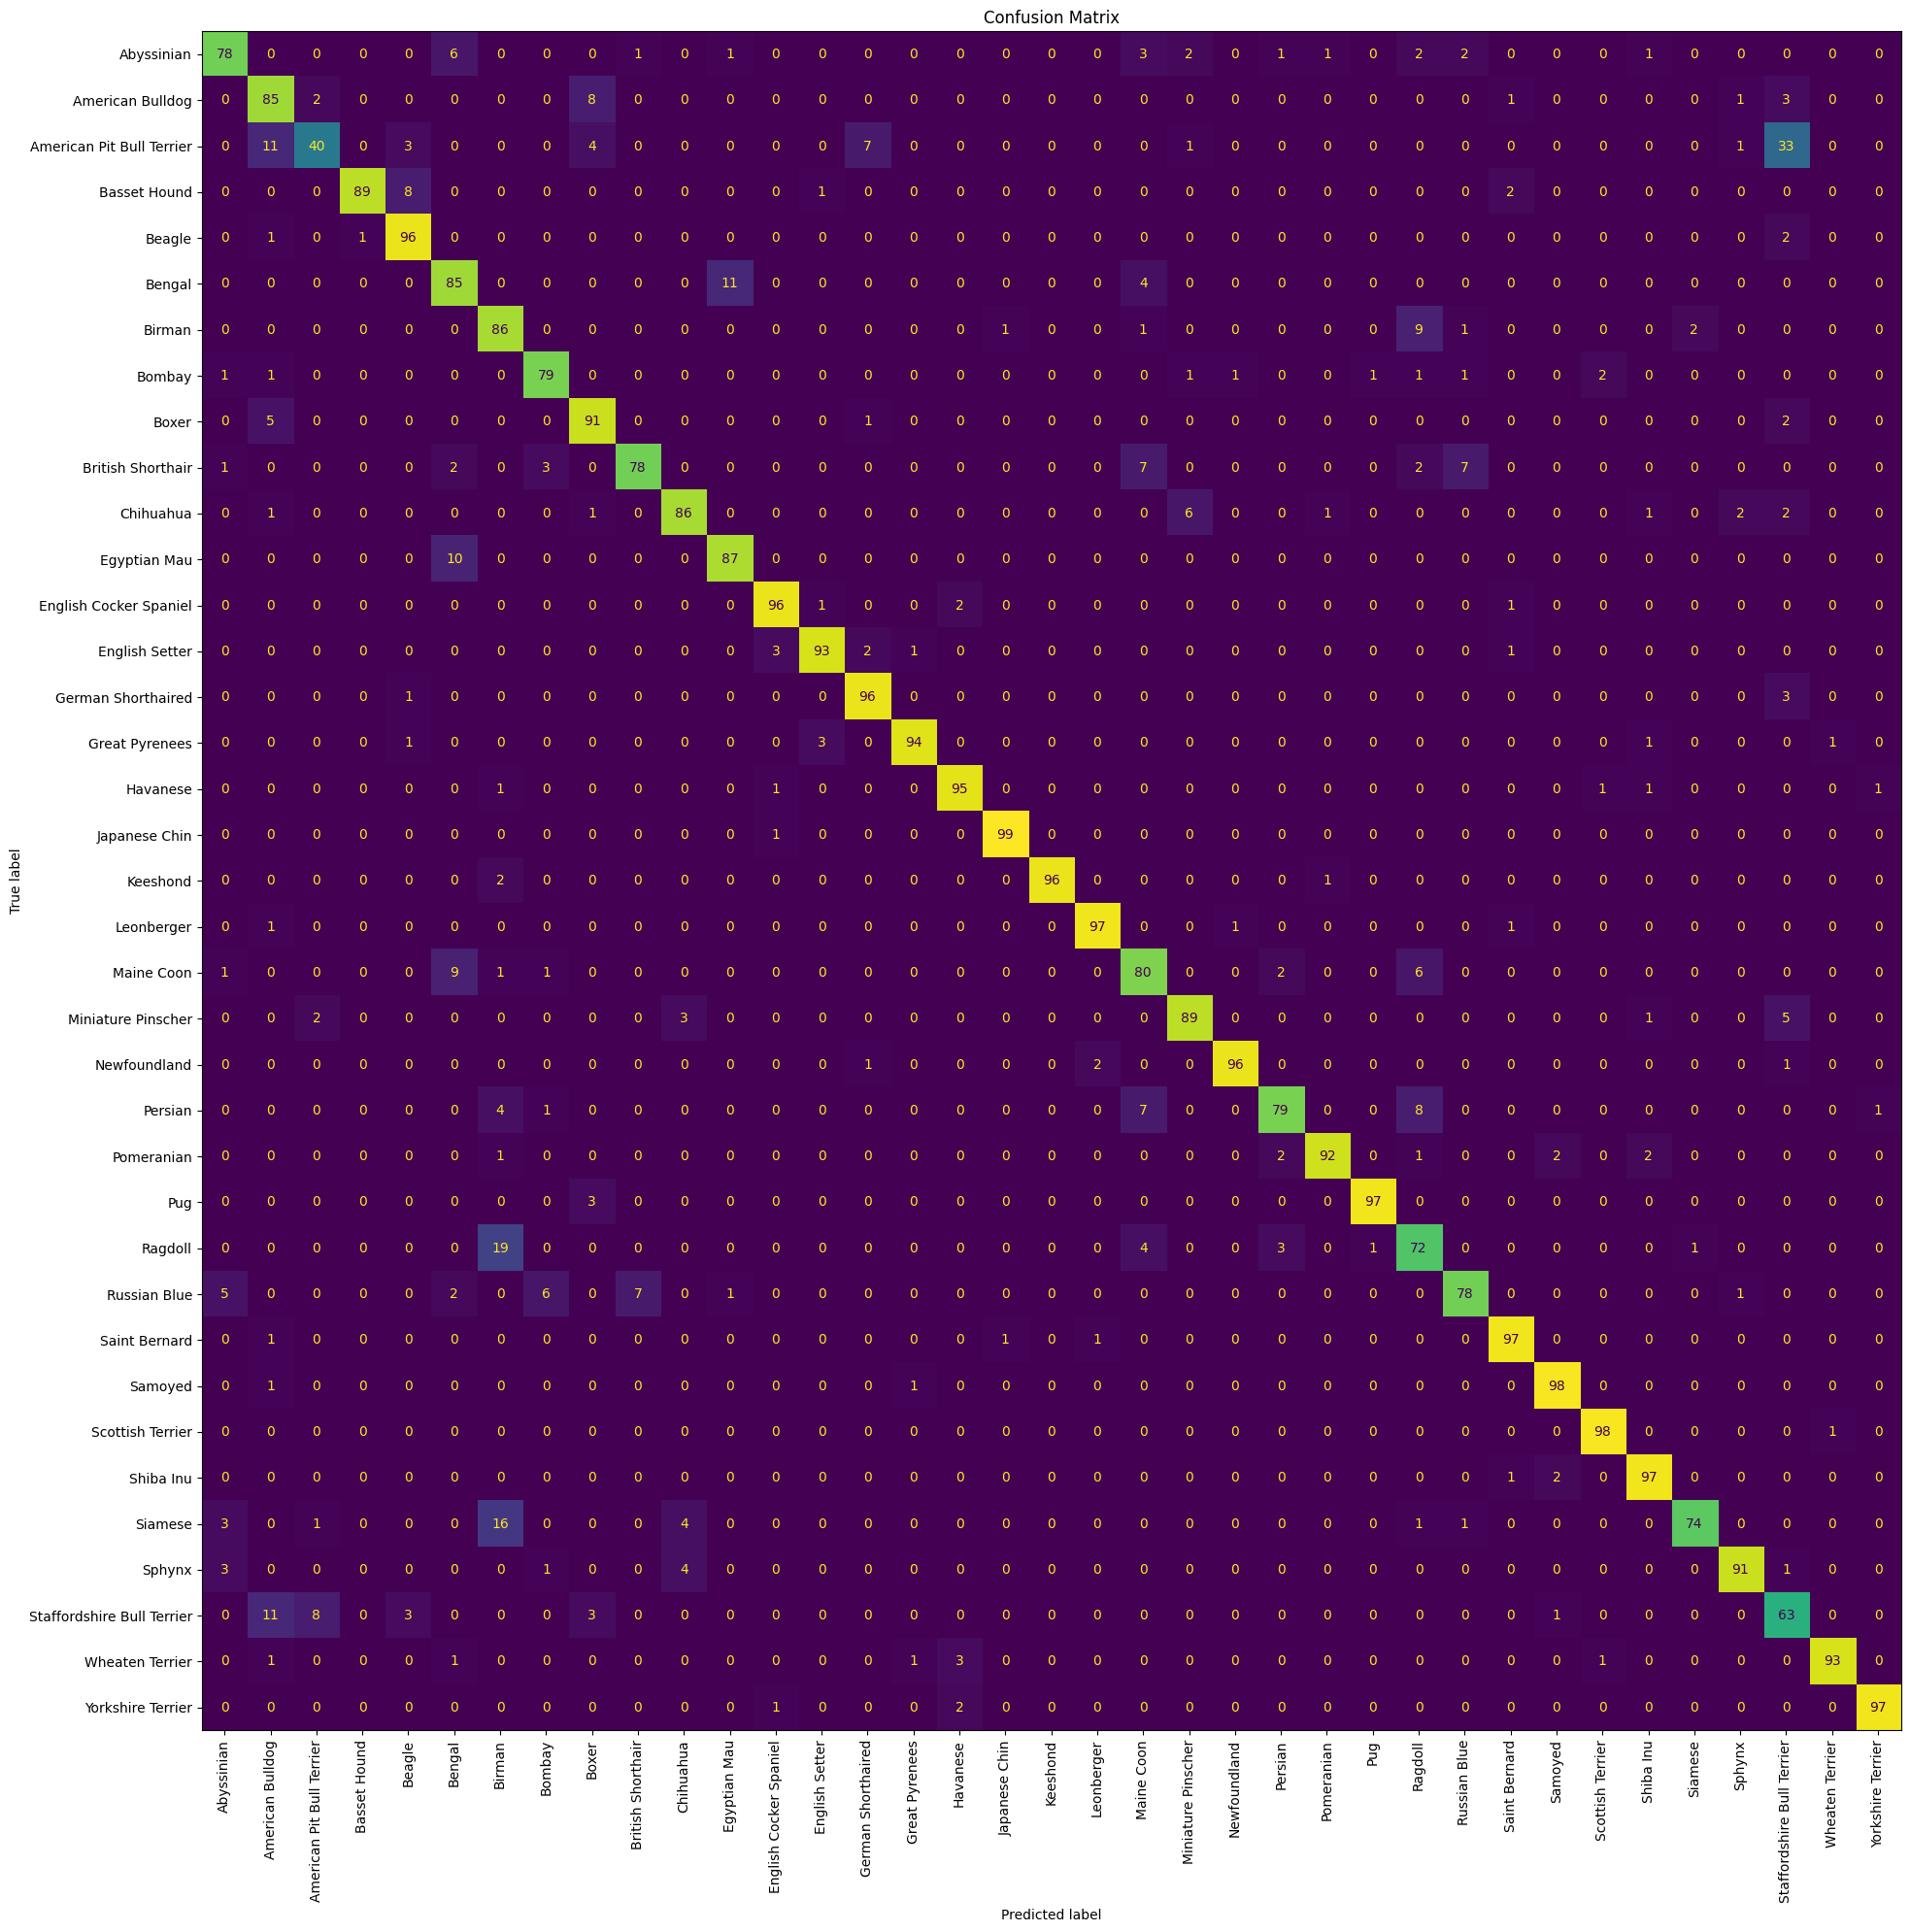

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(20, 20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## Misclassifications

Visualizing failure cases helps identify structural model weaknesses. Indices are shuffled before collection to sample errors from across all classes rather than the alphabetically first ones.

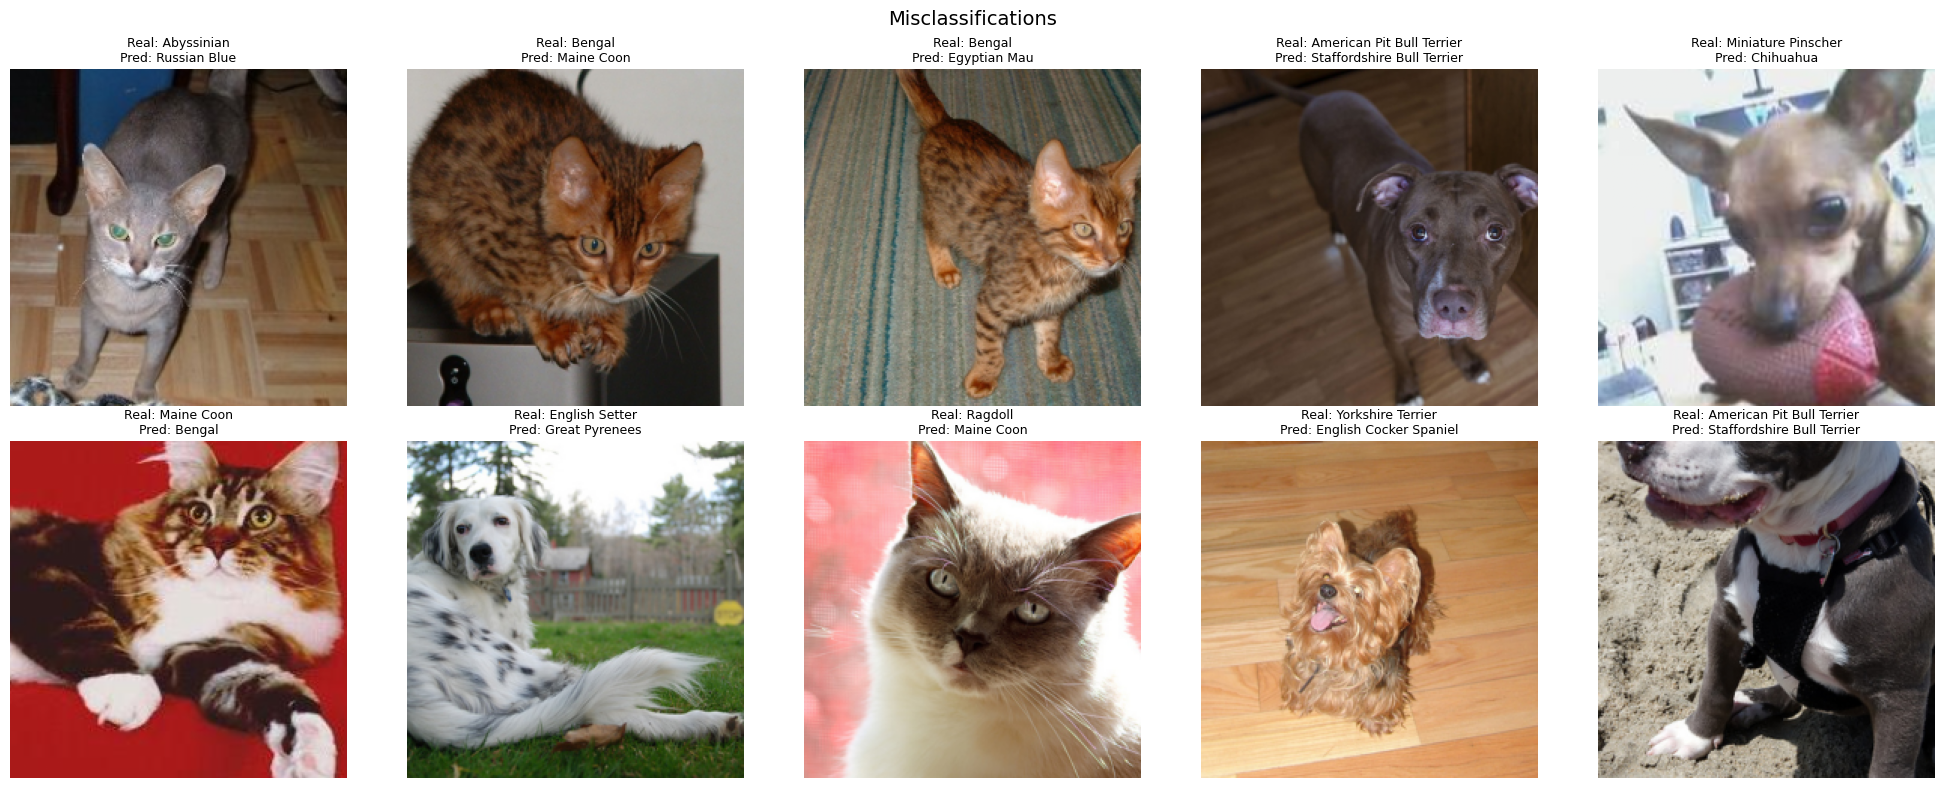

In [14]:
import random

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

wrong_images = []
wrong_preds  = []
wrong_labels = []

shuffled_indices = list(range(len(test_data)))
random.shuffle(shuffled_indices)

model.eval()
with torch.no_grad():
    for idx in shuffled_indices:
        image, label = test_data[idx]
        output = model(image.unsqueeze(0).to(device))
        pred = output.argmax(1).item()
        if pred != label:
            wrong_images.append(image)
            wrong_preds.append(pred)
            wrong_labels.append(label)
        if len(wrong_images) >= 10:
            break

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, ax in enumerate(axes.flat):
    img = denormalize(wrong_images[i]).permute(1, 2, 0)
    ax.imshow(img)
    ax.set_title(f'Real: {class_names[wrong_labels[i]]}\nPred: {class_names[wrong_preds[i]]}', fontsize=9)
    ax.axis('off')

plt.suptitle('Misclassifications', fontsize=14)
plt.tight_layout()
plt.show()

**Insights:**

- Most errors occur between visually similar breeds: Staffordshire Bull Terrier vs American Pit Bull Terrier, Bengal vs Abyssinian, Ragdoll vs Birman
- Cross-species errors (cat predicted as dog) are rare, suggesting the model learned species-level features reliably
- These failure patterns are consistent with human-level difficulty on fine-grained breed identification

## Save Predictions for App

In [15]:
import numpy as np
np.save('all_preds.npy', np.array(all_preds))
np.save('all_labels.npy', np.array(all_labels))
print('Saved all_preds.npy and all_labels.npy')

Saved all_preds.npy and all_labels.npy


# Benchmark: ResNet18 vs Gemini 2.5 Flash-Lite

A sample of 15 test images is sent to both the fine-tuned model and Gemini 2.5 Flash-Lite via API. Gemini receives the same image and a list of the 37 valid class names, and must respond with exactly one. This evaluates whether a general-purpose vision LLM can match a task-specific fine-tuned model on this narrow classification task.

**Trade-offs to consider:** A fine-tuned model runs locally at zero marginal cost per inference, with full data privacy. Gemini costs per API call, introduces network latency, and requires prompt engineering to constrain outputs. However, Gemini requires no training data or compute investment.

In [27]:
import os, time, base64
from io import BytesIO
from PIL import Image
from dotenv import load_dotenv
from google import genai
from google.genai import types
import io


load_dotenv(override=True)
api_key = os.getenv('GOOGLE_API_KEY')
client = genai.Client(api_key=api_key)

def image_to_base64(tensor):
    img = denormalize(tensor).permute(1, 2, 0).numpy()
    img = (img * 255).astype('uint8')
    pil_img = Image.fromarray(img)
    buffer = io.BytesIO()
    pil_img.save(buffer, format='JPEG')
    return base64.b64encode(buffer.getvalue()).decode('utf-8')

test_loader_viz = DataLoader(test_data, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
images, labels = next(iter(test_loader_viz))

sample_image = images[0]
sample_label = labels[0]

prompt = f'''You are a pet breed classifier. Given this image, identify the breed.
You must respond with ONLY one of these exact class names, nothing else:
{', '.join(class_names)}'''

response = client.models.generate_content(
    model='gemini-2.5-flash-lite',
    contents=[
        types.Part.from_bytes(
            data=base64.b64decode(image_to_base64(sample_image.cpu())),
            mime_type='image/jpeg'
        ),
        prompt
    ]
)

print('Gemini predicts:', response.text.strip())
print('Real Label:', class_names[sample_label.item()])

Gemini predicts: German Shorthaired
Real Label: German Shorthaired


In [28]:
import time
import random

n_samples = 10
gemini_correct = 0
model_correct = 0
results = []

loader_iter = iter(test_loader_viz)

for i in range(n_samples):
    try:
        image, label = next(loader_iter)
    except StopIteration:
        loader_iter = iter(test_loader_viz)
        image, label = next(loader_iter)

    image = image[0]
    label = label[0]

    real_class = class_names[label.item()]

    with torch.no_grad():
        output = model(image.unsqueeze(0).to(device))
        pred = output.argmax(1).item()

    model_pred = class_names[pred]
    model_ok = pred == label.item()
    if model_ok:
        model_correct += 1

    response = client.models.generate_content(
        model='gemini-2.5-flash-lite',
        contents=[
            types.Part.from_bytes(
                data=base64.b64decode(image_to_base64(image)),
                mime_type='image/jpeg'
            ),
            prompt
        ]
    )

    gemini_pred = response.text.strip()
    gemini_ok = gemini_pred == real_class
    if gemini_ok:
        gemini_correct += 1

    results.append({
        'real': real_class,
        'model_pred': model_pred,
        'model_ok': model_ok,
        'gemini_pred': gemini_pred,
        'gemini_ok': gemini_ok
    })

    print(
        f'[{i+1:02d}/{n_samples}] '
        f'Real: {real_class:<30} | '
        f'Model: {model_pred:<30} {"correct" if model_ok else "wrong"} | '
        f'Gemini: {gemini_pred:<30} {"correct" if gemini_ok else "wrong"}'
    )

    time.sleep(12.1)

print(f'\nResNet18 fine-tuned: {model_correct/n_samples:.2%}')
print(f'Gemini 2.5 Flash-Lite: {gemini_correct/n_samples:.2%}')

[01/10] Real: English Setter                 | Model: English Setter                 correct | Gemini: English Setter                 correct
[02/10] Real: Wheaten Terrier                | Model: Wheaten Terrier                correct | Gemini: Wheaten Terrier                correct
[03/10] Real: Staffordshire Bull Terrier     | Model: Staffordshire Bull Terrier     correct | Gemini: American Pit Bull Terrier      wrong
[04/10] Real: Bengal                         | Model: Bengal                         correct | Gemini: Bengal                         correct
[05/10] Real: Havanese                       | Model: Havanese                       correct | Gemini: Havanese                       correct
[06/10] Real: Newfoundland                   | Model: Newfoundland                   correct | Gemini: Newfoundland                   correct
[07/10] Real: Staffordshire Bull Terrier     | Model: Staffordshire Bull Terrier     correct | Gemini: American Pit Bull Terrier      wrong
[08/10] Re

**Insights:**

- Both models achieved 90% and 80% accuracy respectively on this 10-sample batch, indicating that commonly well-represented breeds are recognizable by both a task-specific model and a general-purpose LLM
- The real differentiator appears on hard cases: the full test set reveals the fine-tuned model struggles with Staffordshire Bull Terrier vs Pit Bull (F1 0.56-0.62), and Gemini would likely face similar challenges
- For production use, cost per inference and data privacy are the decisive factors, not raw accuracy on typical images

# Conclusions

## Summary

A ResNet18 backbone pretrained on ImageNet was fine-tuned by replacing the final fully connected layer and training it exclusively on 2,944 images from the Oxford-IIIT Pets dataset. The model achieved 88.3% test accuracy across 37 fine-grained pet breeds, with a macro F1-score of 0.88.

The benchmark against Gemini 2.5 Flash-Lite showed both models performing comparably on a 10-image sample, reinforcing the argument that task-specific models are viable alternatives to large vision LLMs for narrow classification problems, with the added benefits of zero per-call cost and full data privacy.

## Future Work

Three directions could meaningfully improve performance:

1. Gradual unfreezing: After the classification head converges, unfreeze the last residual blocks (layer3 and layer4 in ResNet18) and fine-tune with a lower learning rate (1e-4 or less). This allows the backbone to adapt its higher-level features to pet-specific visual patterns rather than relying solely on general ImageNet representations.

2. Stronger backbone: ResNet18 is the smallest ResNet variant. Switching to EfficientNet-B4 or a Vision Transformer (ViT-B/16) would provide a higher-capacity feature extractor, likely improving performance on the hardest classes without requiring more training data.

3. Class-aware augmentation: Applying Mixup or CutMix specifically for the confused class pairs (Staffordshire vs Pit Bull, Bengal vs Abyssinian) could improve decision boundaries in the regions where the model currently fails most.